<a href="https://colab.research.google.com/github/wawaelenti/Machine-Learning/blob/main/KMeans_Manhattan.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 📐 1. Formulasi Matematis Manhattan Distance & Fungsi Objektif

### 1.1. Manhattan Distance ($L_1$ Norm)
Jarak Manhattan menjumlahkan selisih absolut setiap fitur:
$$d_{\mathrm{Manhattan}}(x,y)=\sum_{i=1}^{p}|x_i-y_i|.$$

### 1.2. Fungsi Objektif (Sum of Absolute Errors / SAE)
K-Medians meminimalkan jumlah jarak Manhattan ke pusat klaster:
$$J=\sum_{j=1}^{K}\sum_{x\in S_j}\lVert x-\mu_j\rVert_1.$$
Pusat klaster diperbarui dengan median tiap fitur:
$$\mu_{j,i}=\operatorname{median}\{x_i:x\in S_j\}.$$

Notebook mempertahankan implementasi K-Medians dan inisialisasi berbasis
jarak Manhattan. Semua baris dataset dipakai; `status` hanya digunakan
untuk analisis hasil, dan PCA untuk visualisasi.

In [ ]:
# =======================================================================
# 1. SETUP & IMPORT LIBRARY
# =======================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import VarianceThreshold
from sklearn.decomposition import PCA
from sklearn.metrics import pairwise_distances, silhouette_score

RANDOM_STATE = 42
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['font.size'] = 11
plt.rcParams['figure.dpi'] = 120


In [ ]:
# =======================================================================
# 2. DATASET & PREPROCESSING
# =======================================================================
FILE = 'dataset_B_05_2020 (1).csv'
df = pd.read_csv(FILE)

print('Shape dataset:', df.shape)
print('Jumlah data:', df.shape[0])
print('Jumlah kolom:', df.shape[1])
display(df.head(3))

# Metadata dan label asli disimpan terpisah dari fitur clustering.
urls = df['url'].copy()
y_true = df['status'].copy()
labels = y_true.copy()
X = df.drop(columns=['url', 'status']).select_dtypes(include=np.number)
print('Shape fitur numerik:', X.shape)

# Imputasi median, penghapusan fitur konstan, lalu StandardScaler.
print('Missing value sebelum imputasi:', int(X.isna().sum().sum()))
X = X.fillna(X.median())
print('Missing value setelah imputasi:', int(X.isna().sum().sum()))

selector = VarianceThreshold(threshold=0)
X_sel = selector.fit_transform(X)
selected_features = X.columns[selector.get_support()]
removed_features = X.columns[~selector.get_support()]
X_selected = pd.DataFrame(X_sel, columns=selected_features, index=X.index)
print('Fitur konstan yang dihapus:', list(removed_features))
print('Shape setelah seleksi fitur:', X_selected.shape)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_selected)
df_after = pd.DataFrame(X_scaled, columns=selected_features, index=X.index)
print('Shape setelah StandardScaler:', X_scaled.shape)
display(df_after.head(3))


Shape dataset: (11430, 89)
Jumlah data: 11430
Jumlah kolom: 89


,url,length_url,length_hostname,ip,nb_dots,nb_hyphens,nb_at,nb_qm,nb_and,nb_or,...,domain_in_title,domain_with_copyright,whois_registered_domain,domain_registration_length,domain_age,web_traffic,dns_record,google_index,page_rank,status
0,http://www.crestonwood.com/router.php,37,19,0,3,0,0,0,0,0,...,0,1,0,45,-1,0,1,1,4,legitimate
1,http://shadetreetechnology.com/V4/validation/a...,77,23,1,1,0,0,0,0,0,...,1,0,0,77,5767,0,0,1,2,phishing
2,https://support-appleld.com.secureupdate.duila...,126,50,1,4,1,0,1,2,0,...,1,0,0,14,4004,5828815,0,1,0,phishing


Shape fitur numerik: (11430, 87)
Missing value sebelum imputasi: 0
Missing value setelah imputasi: 0
Fitur konstan yang dihapus: ['nb_or', 'ratio_nullHyperlinks', 'ratio_intRedirection', 'ratio_intErrors', 'submit_email', 'sfh']
Shape setelah seleksi fitur: (11430, 81)
Shape setelah StandardScaler: (11430, 81)


,length_url,length_hostname,ip,nb_dots,nb_hyphens,nb_at,nb_qm,nb_and,nb_eq,nb_underscore,...,empty_title,domain_in_title,domain_with_copyright,whois_registered_domain,domain_registration_length,domain_age,web_traffic,dns_record,google_index,page_rank
0,-0.436327,-0.193964,-0.421020,0.379116,-0.477984,-0.142915,-0.387464,-0.197604,-0.293683,-0.295128,...,-0.377549,-1.860473,1.129194,-0.28037,-0.549299,-1.307594,-0.429340,6.978227,0.934264,0.320974
1,0.287067,0.177207,2.375182,-1.081136,-0.477984,-0.142915,-0.387464,-0.197604,-0.293683,-0.295128,...,-0.377549,0.537498,-0.885587,-0.28037,-0.510022,0.548471,-0.429340,-0.143303,0.934264,-0.467407
2,1.173224,2.682613,2.375182,1.109242,0.001174,-0.142915,2.356473,2.237556,2.711505,1.534217,...,-0.377549,0.537498,-0.885587,-0.28037,-0.587348,-0.018839,2.491612,-0.143303,0.934264,-1.255788


## 📈 2. Penentuan Jumlah Klaster (Elbow Method Manhattan)

Nilai SAE dan Silhouette Manhattan dihitung untuk $k=2,\ldots,10$.
Titik siku dipilih dari jarak terbesar kurva SAE yang dinormalisasi terhadap
garis penghubung kedua ujung. Model akhir menggunakan $k$ hasil Elbow,
dengan `n_init=20`; pengujian kurva menggunakan `n_init=10`.
$$\mathrm{SAE}(k)=\sum_{j=1}^{k}\sum_{x\in S_j}\lVert x-\mu_j\rVert_1.$$

In [ ]:
# =======================================================================
# 3. IMPLEMENTASI K-MEDIANS MANHATTAN
# =======================================================================
def manhattan_to_centroids(X, C):
    return pairwise_distances(X, C, metric="manhattan")


def init_centroids_pp(X, k, rng):
    """Seeding ala k-means++ memakai jarak Manhattan."""
    n = X.shape[0]
    centers = [X[rng.integers(n)]]
    d = manhattan_to_centroids(X, np.array(centers)).min(axis=1)
    for _ in range(1, k):
        probs = d / d.sum()
        centers.append(X[rng.choice(n, p=probs)])
        d = np.minimum(d, manhattan_to_centroids(X, np.array(centers[-1:])).ravel())
    return np.array(centers)


def kmedians_single(X, k, max_iter=300, tol=1e-6, rng=None):
    rng = rng or np.random.default_rng(RANDOM_STATE)
    C = init_centroids_pp(X, k, rng)

    for it in range(max_iter):
        D = manhattan_to_centroids(X, C)
        labels = D.argmin(axis=1)

        C_new = C.copy()
        for j in range(k):
            members = X[labels == j]
            if len(members) > 0:
                C_new[j] = np.median(members, axis=0)      # centroid = MEDIAN
            else:
                # cluster kosong -> pindahkan ke titik terjauh dari centroid-nya
                far = D[np.arange(len(X)), labels].argmax()
                C_new[j] = X[far]

        shift = np.abs(C_new - C).sum()
        C = C_new
        if shift < tol:
            break

    D = manhattan_to_centroids(X, C)
    labels = D.argmin(axis=1)
    cost = D[np.arange(len(X)), labels].sum()
    return labels, C, cost, it + 1


def kmedians(X, k, n_init=10, max_iter=300, seed=RANDOM_STATE):
    best = None
    for s in range(n_init):
        rng = np.random.default_rng(seed + s)
        res = kmedians_single(X, k, max_iter=max_iter, rng=rng)
        if best is None or res[2] < best[2]:
            best = res
    return best   # labels, centroids, cost, n_iter


K= 2 | Total Manhattan=   342517.12 | Silhouette(L1)=0.1001 | iter=9


K= 3 | Total Manhattan=   325824.02 | Silhouette(L1)=0.1174 | iter=12


K= 4 | Total Manhattan=   315416.00 | Silhouette(L1)=0.1130 | iter=27


K= 5 | Total Manhattan=   305458.54 | Silhouette(L1)=0.0505 | iter=31


K= 6 | Total Manhattan=   298057.24 | Silhouette(L1)=0.0700 | iter=16


K= 7 | Total Manhattan=   289579.77 | Silhouette(L1)=0.0759 | iter=13


K= 8 | Total Manhattan=   287255.61 | Silhouette(L1)=0.0657 | iter=17


K= 9 | Total Manhattan=   284391.07 | Silhouette(L1)=0.0696 | iter=19


K=10 | Total Manhattan=   280960.09 | Silhouette(L1)=0.0772 | iter=20

Cek monoton turun: True
K optimal (Elbow)      : 7
K terbaik (Silhouette) : 3


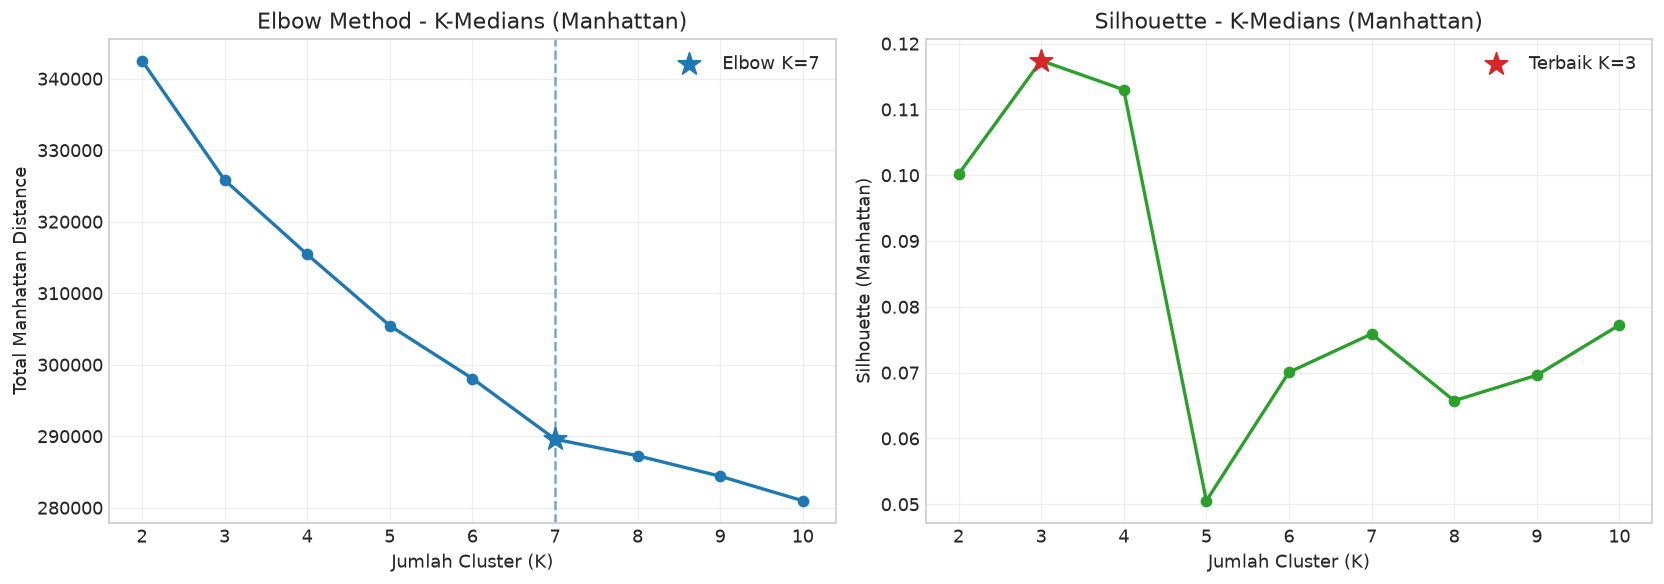

In [ ]:
# =======================================================================
# 4. ELBOW MANHATTAN & EVALUASI JUMLAH KLASTER
# =======================================================================
K_range = list(range(2, 11))
costs, sils, models = [], [], {}

for k in K_range:
    labels_k, cent_k, cost_k, n_it = kmedians(X_scaled, k, n_init=10)

    # Silhouette dengan jarak Manhattan
    sil_k = silhouette_score(
        X_scaled, labels_k, metric="manhattan",
    )

    costs.append(cost_k); sils.append(sil_k); models[k] = (labels_k, cent_k)
    print(f"K={k:2d} | Total Manhattan={cost_k:12.2f} | Silhouette(L1)={sil_k:.4f} | iter={n_it}")

print("\nCek monoton turun:", all(np.diff(costs) <= 1e-6))

x = np.array(K_range, dtype=float)
y = np.array(costs, dtype=float)
xn = (x - x.min()) / (x.max() - x.min())
yn = (y - y.min()) / np.ptp(y) if np.ptp(y) > 0 else np.zeros_like(y)

# garis dari (0,1) ke (1,0): x + y - 1 = 0
dist_line = np.abs(xn + yn - 1) / np.sqrt(2)

optimal_k = K_range[int(np.argmax(dist_line))]
best_sil_k = K_range[int(np.argmax(sils))]
print("K optimal (Elbow)      :", optimal_k)
print("K terbaik (Silhouette) :", best_sil_k)

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

ax[0].plot(K_range, costs, marker="o", lw=2)
ax[0].scatter(optimal_k, costs[K_range.index(optimal_k)], s=200, marker="*", zorder=5,
              label=f"Elbow K={optimal_k}")
ax[0].axvline(optimal_k, ls="--", alpha=.6)
ax[0].set(xlabel="Jumlah Cluster (K)", ylabel="Total Manhattan Distance",
          title="Elbow Method - K-Medians (Manhattan)")
ax[0].set_xticks(K_range); ax[0].grid(alpha=.3); ax[0].legend()

ax[1].plot(K_range, sils, marker="o", lw=2, color="tab:green")
ax[1].scatter(best_sil_k, max(sils), s=200, marker="*", zorder=5, color="tab:red",
              label=f"Terbaik K={best_sil_k}")
ax[1].set(xlabel="Jumlah Cluster (K)", ylabel="Silhouette (Manhattan)",
          title="Silhouette - K-Medians (Manhattan)")
ax[1].set_xticks(K_range); ax[1].grid(alpha=.3); ax[1].legend()

plt.tight_layout(); plt.show()


In [ ]:
# =======================================================================
# 5. EKSEKUSI CLUSTERING & METRIK EVALUASI
# =======================================================================
K_FINAL = optimal_k

cluster_labels, centroids, final_cost, n_iter = kmedians(X_scaled, K_FINAL, n_init=20)

df_clustered = df.copy()
df_clustered["cluster"] = cluster_labels

print(f"K-Medians (Manhattan) selesai | K={K_FINAL} | iter={n_iter} | total L1={final_cost:.2f}")
print("\nJumlah data per cluster:")
print(df_clustered["cluster"].value_counts().sort_index())

ct = pd.crosstab(df_clustered["cluster"], y_true)
print(ct, "\n")


sil_full = silhouette_score(X_scaled, cluster_labels, metric="manhattan")

print(f"Silhouette (Manhattan): {sil_full:.4f}")

eval_df = pd.DataFrame([{
    'Distance Metric': 'Manhattan',
    'K yang Dipilih': K_FINAL,
    'Jumlah Klaster': len(np.unique(cluster_labels)),
    'Silhouette Score': sil_full,
    'Objective Value (SAE)': final_cost,
    'Iterations': n_iter,
}])
display(eval_df.round(4))
display(ct)


K-Medians (Manhattan) selesai | K=7 | iter=13 | total L1=289579.77

Jumlah data per cluster:
cluster
0     902
1    2410
2    1537
3     380
4    1962
5    2135
6    2104
Name: count, dtype: int64
status   legitimate  phishing
cluster                      
0                17       885
1              2137       273
2               361      1176
3                 0       380
4              1900        62
5               793      1342
6               507      1597 



Silhouette (Manhattan): 0.0759


,Distance Metric,K yang Dipilih,Jumlah Klaster,Silhouette Score,Objective Value (SAE),Iterations
0,Manhattan,7,7,0.0759,289579.7696,13


status,legitimate,phishing
cluster,,
0,17,885
1,2137,273
2,361,1176
3,0,380
4,1900,62
5,793,1342
6,507,1597


Explained variance ratio: [0.10140136 0.05367566] | total: 0.15507701974956692


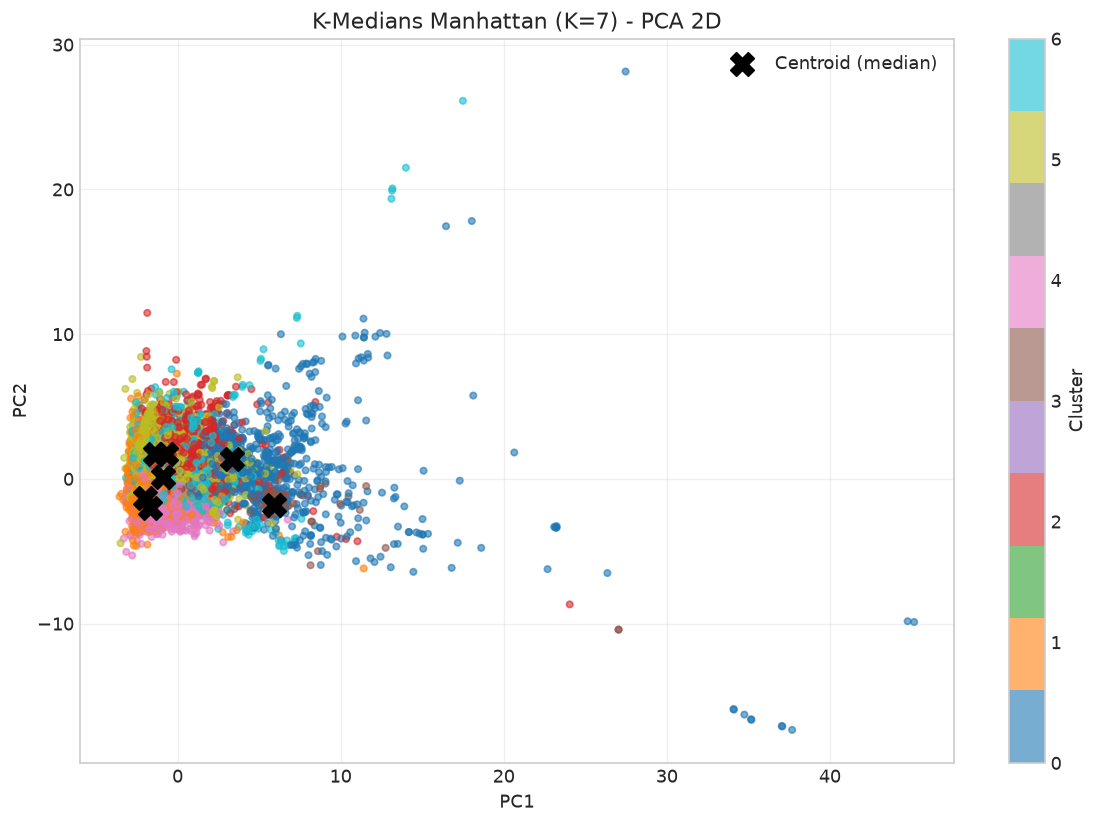

In [ ]:
# =======================================================================
# 6. VISUALISASI PCA 2D PEMETAAN KLASTER & CENTROIDS
# =======================================================================
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_2d = pca.fit_transform(X_scaled)
C_2d = pca.transform(centroids)
print("Explained variance ratio:", pca.explained_variance_ratio_, "| total:", pca.explained_variance_ratio_.sum())

plt.figure(figsize=(10, 7))
sc = plt.scatter(X_2d[:, 0], X_2d[:, 1], c=cluster_labels, cmap="tab10", s=15, alpha=.6)
plt.scatter(C_2d[:, 0], C_2d[:, 1], c="black", marker="X", s=200, label="Centroid (median)")
plt.colorbar(sc, label="Cluster")
plt.xlabel("PC1"); plt.ylabel("PC2")
plt.title(f"K-Medians Manhattan (K={K_FINAL}) - PCA 2D")
plt.legend(); plt.grid(alpha=.3); plt.tight_layout(); plt.show()
